# CSCI/MATH 485 Assignment
## Customer Churn Prediction with XGBoost
## Starter Notebook

This notebook is compatible with **Jupyter Notebook** and **Google Colab**.

This starter code is only to get you started. You can change any of the existing code here to complete all the tasks.

Complete all `TODO` sections. Make sure your final submission includes:
- data analysis,
- a tuned XGBoost model,
- your chosen main evaluation metric and justification,
- interpretation of top important features,
- and a final comparison with the baseline model.


## 1. Setup


In [ ]:
# If you are using Google Colab, uncomment the next line if xgboost is not installed.
# !pip install xgboost


In [10]:
import pandas as pd
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier


## 2. Load the Dataset

**Instructions for students**
- Load the IBM Telco Customer Churn dataset.
- Display the first few rows.
- Confirm the dataset shape.
- If the url doesn't work for you, download the csv file from the Canvas Assignment#4

In [50]:
#url = "https://raw.githubusercontent.com/plotly/datasets/master/telco-customer-churn-by-IBM.csv"
file = open('telco-customer-churn-by-IBM.csv')
df = pd.read_csv(file)

# Display the first 5 rows of the dataset (done below)
df.head()

# TODO:
# Display the shape of the dataset
shape = df.shape
print(shape)

(7043, 21)


## 3. Data Exploration

Complete the following:
- Print all column names
- Show data types
- Count missing values in each column
- Show the distribution of the target variable
- Write a short note: Is this a classification or regression problem? Why is this useful in business?


Columns:
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

Data types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: objec

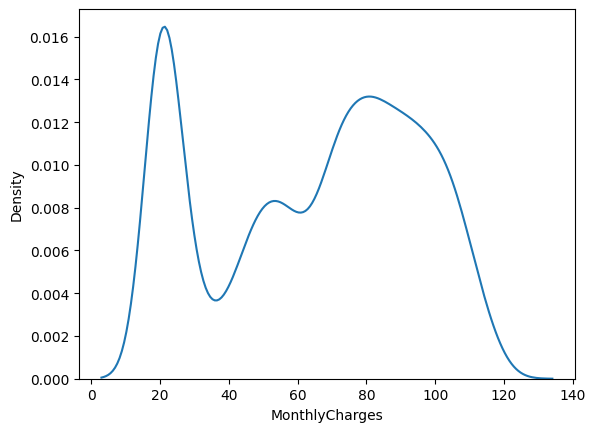

In [51]:
# TODO:
# Print column names
# Print data types
# Print missing values for each column
# Print value counts for the target column

print("Columns:")
# your code here
cols = df.columns
print(cols)

print("\nData types:")
# your code here
dtypes = df.dtypes
print(dtypes)

print("\nMissing values:")
# your code here
mVals = df.isnull() # .isna() ?
print(mVals)

print("\nTarget distribution:")
# yourcode here


tDist = df['Churn'].value_counts()

print(tDist)
    
# Extra: display other information of the dataset that you think can be useful
print("Monthly Charges density plot")
sns.kdeplot(data=df, x='MonthlyCharges')
#sns.kdeplot(data=df, x='tenure')
print("Contract values")
print(df['Contract'].value_counts())

print("Tenure quantiles:")
print(df['tenure'].quantile([0, 0.25, 0.5, 0.75, 1]))

print("Head:")
print(df.head())

print("Print all values for string variables:")
print(df.select_dtypes(include=['string']).apply(pd.Series.unique))

print("Print all values for PaymentMethod")
print(df['PaymentMethod'].unique())

print("Print all values for SeniorCitizen")
print(df['SeniorCitizen'].unique())



**TODO (write your answer below):**

1. What kind of machine learning problem is this?
2. Why is churn prediction important in a business setting?

_Replace this text with your answer._

I would go with a Bayesian Network, since it looks like the majority of the variables reduce to simple TRUE/FALSE results, which allow for the required conditional probabilities.
I'm a little concerned at how I would incorporate the MonthlyCharges variable, since cost I would a priori expect cost to be a significant factor in customer's choice to end service.

Reducing churn when providing ongoing services leads to an increased customer base.


## 4. Basic Cleaning

Complet the following:
- Identify whether there is an ID column that should be removed
- Convert the target column into binary form if needed
- Convert any numeric-looking columns stored as text into numeric values


In [58]:
# Make a copy so the original data remains unchanged
df_clean = df.copy()

# TODO:
# 1. Drop any unnecessary identifier column(s)
# 2. Convert the target column to 0/1
# 3. Convert any columns that should be numeric into numeric type
# 4. Handle invalid parsing if needed

df_clean = df_clean.drop(columns=['customerID',
                                  'PaymentMethod',
                                  'MultipleLines',
                                  'Contract'])
# Yes/Nos
df_clean["Churn"] = df_clean["Churn"].map({"Yes": 1, "No": 0})
## Apparently I was overthinking things:
#df_clean["Partner"] = df_clean["Partner"].map({"Yes": 1, "No": 0})
#df_clean["PhoneService"] = df_clean["PhoneService"].map({"Yes": 1, "No": 0})
#df_clean["OnlineSecurity"] = df_clean["OnlineSecurity"].map({"Yes": 1, "No": 0})
#df_clean["OnlineBackup"] = df_clean["OnlineBackup"].map({"Yes": 1, "No": 0})
#df_clean["DeviceProtection"] = df_clean["DeviceProtection"].map({"Yes": 1, "No": 0})

#df_clean["TechSupport"] = df_clean["TechSupport"].map({"Yes": 1, "No": 0})
#df_clean["StreamingTV"] = df_clean["StreamingTV"].map({"Yes": 1, "No": 0})
#df_clean["StreamingMovies"] = df_clean["StreamingMovies"].map({"Yes": 1, "No": 0})
#df_clean["PaperlessBilling"] = df_clean["PaperlessBilling"].map({"Yes": 1, "No": 0})
#df_clean["Dependents"] = df_clean["Dependents"].map({"Yes": 1, "No": 0})


df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors="coerce")
#df_clean[""] = df_clean[""].map({"Yes": 1, "No": 0})

# df_clean = df_clean.drop(columns=[...])
# df_clean["Churn"] = df_clean["Churn"].map({"Yes": 1, "No": 0})
# df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"], errors="coerce")
print(df_clean['TotalCharges'].dtype)
df_clean.head()


float64


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,DSL,No,Yes,No,No,No,No,Yes,29.85,29.85,0
1,Male,0,No,No,34,Yes,DSL,Yes,No,Yes,No,No,No,No,56.95,1889.50,0
2,Male,0,No,No,2,Yes,DSL,Yes,Yes,No,No,No,No,Yes,53.85,108.15,1
3,Male,0,No,No,45,No,DSL,Yes,No,Yes,Yes,No,No,No,42.30,1840.75,0
4,Female,0,No,No,2,Yes,Fiber optic,No,No,No,No,No,No,Yes,70.70,151.65,1


## 5. Define Features and Target

Complet the following:
- Define `X` and `y`
- Set the correct target column


In [59]:
# TODO:
# Replace with the correct target column name
target_col = "Churn"

X = df_clean.drop(columns=[target_col])
y = df_clean[target_col]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)


Feature matrix shape: (7043, 16)
Target shape: (7043,)


## 6. Identify Numeric and Categorical Features

Complet the following:
- Create a list of numeric columns
- Create a list of categorical columns


In [69]:
# TODO:
# Identify numeric and categorical feature columns

numeric_features = ['MonthlyCharges',
                    'TotalCharges',
                    'tenure']

categorical_features = ['gender',
                       'SeniorCitizen',
                       'Partner',
                       'Dependents',
                       'PhoneService',
                       'InternetService',
                       'OnlineSecurity',
                       'OnlineBackup',
                       'DeviceProtection',
                       'TechSupport',
                       'StreamingTV',
                       'StreamingMovies',
                       'PaperlessBilling']

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)


Numeric features:
['MonthlyCharges', 'TotalCharges', 'tenure']

Categorical features:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling']


## 7. Train/Test Split

Complet the following:
- Split the dataset into training and testing sets
- Use stratification if appropriate


In [70]:
# TODO:
# Create train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


X_train shape: (5634, 16)
X_test shape: (1409, 16)


## 8. Preprocessing Pipelines

Build preprocessing for:
- numeric features
- categorical features

Then combine them into a `ColumnTransformer`.


In [71]:
# TODO:
# Build numeric preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    # Example:
    # ("imputer", SimpleImputer(strategy="median"))
    ("num_imputer", SimpleImputer(strategy="median"))
])

# TODO:
# Build categorical preprocessing pipeline
categorical_transformer = Pipeline(steps=[
    # Example:
    # ("imputer", SimpleImputer(strategy="most_frequent")),
    # ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ("cat_impputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# TODO:
# Combine both preprocessing pipelines
preprocessor = ColumnTransformer(transformers=[
    # Example:
    # ("num", numeric_transformer, numeric_features),
    # ("cat", categorical_transformer, categorical_features)
    ("num_trans", numeric_transformer, numeric_features),
    ("cat_trans", categorical_transformer, categorical_features)
])

preprocessor


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_trans', ...), ('cat_trans', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_na

## 9. Baseline Model: Logistic Regression

Complet the following:
- Train a Logistic Regression model as the baseline
- Generate predictions
- Evaluate using multiple metrics
- You may need to adjust `max_iter` if the model is not converging.


In [125]:
baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=5000))
])

# TODO:
# Fit the baseline model
# Generate predicted labels
# Generate predicted probabilities

# your code here

baseline_model.fit(X_train, y_train)
baseline_pred = baseline_model.predict(X_test)
baseline_prob = baseline_model.predict_proba(X_test)[:, 1]
baseline_pred_30 = 



In [128]:
# TODO:
# Compute and print:
# - Accuracy
print("Accuracy:")
print(accuracy_score(y_test, baseline_pred))
print("0.1:", accuracy_score(y_test, (baseline_prob > 0.1).astype(int)))
print("0.2:", accuracy_score(y_test, (baseline_prob > 0.2).astype(int)))
print("0.3:", accuracy_score(y_test, (baseline_prob > 0.3).astype(int)))
print("0.4:", accuracy_score(y_test, (baseline_prob > 0.4).astype(int)))
print("0.5:", accuracy_score(y_test, (baseline_prob > 0.5).astype(int)))
print("0.6:", accuracy_score(y_test, (baseline_prob > 0.6).astype(int)))
print("0.7:", accuracy_score(y_test, (baseline_prob > 0.7).astype(int)))


# - Precision
print("Precision:")
print(precision_score(y_test, baseline_pred))
# - Recall
print("Recall:")
print(recall_score(y_test, baseline_pred))
# - F1-score
print("F1-Score:")
print(f1_score(y_test, baseline_pred))
print("0.1:", f1_score(y_test, (baseline_prob > 0.1).astype(int)))
print("0.2:", f1_score(y_test, (baseline_prob > 0.2).astype(int)))
print("0.3:", f1_score(y_test, (baseline_prob > 0.3).astype(int)))
print("0.4:", f1_score(y_test, (baseline_prob > 0.4).astype(int)))
print("0.5:", f1_score(y_test, (baseline_prob > 0.5).astype(int)))
print("0.6:", f1_score(y_test, (baseline_prob > 0.6).astype(int)))
print("0.7:", f1_score(y_test, (baseline_prob > 0.7).astype(int)))

# - ROC-AUC
print("ROC-AUC:")
print(roc_auc_score(y_test, baseline_prob))

# Suggested variable names:
# baseline_preds
# baseline_probs

# your code here


Accuracy:
0.7963094393186657
0.1: 0.5848119233498935
0.2: 0.6919801277501775
0.3: 0.7501774308019872
0.4: 0.794889992902768
0.5: 0.7963094393186657
0.6: 0.7899219304471257
0.7: 0.7721788502484032
Precision:
0.639871382636656
Recall:
0.5320855614973262
F1-Score:
0.581021897810219
0.1: 0.5489591364687741
0.2: 0.5890151515151515
0.3: 0.6097560975609756
0.4: 0.6299615877080665
0.5: 0.581021897810219
0.6: 0.4896551724137931
0.7: 0.3408624229979466
ROC-AUC:
0.8363558862280089


In [115]:
# Optional but helpful
# TODO:
# Print classification report and confusion matrix

# your code here
print("Classification Report:")
print(classification_report(y_test, baseline_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, baseline_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1035
           1       0.64      0.53      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409

Confusion Matrix:
[[923 112]
 [175 199]]


## 10. Choose Your Main Evaluation Metric

Choose **one main metric** for this churn problem.

You must explain:
- which metric you chose,
- why it is appropriate,
- and why it is more informative than accuracy alone for this problem.

F1-score seems like the best metric. It's focused to what we are concerned about (Churners), while weighing performance towards non-churners less. Though the default threshold of 0.5 seems too high, 0.4 looks to be better.
It is more informative than Accuracy alone because Accuracy is including how often the model correctly identifies non-churners, who are the vast majority, which will give an inflated metric of performance. It will be technically more correct, but we don't care about the kind of correct it is; much the same as a model which simply "predicts" every integer as "not Prime" will have >95% Accuracy.


**TODO (write your answer below):**

_Replace this text with your answer._


## 11. XGBoost Model

Complet the following:
- Build an XGBoost pipeline
- Tune at least 3 hyperparameters
- Use either `GridSearchCV` or your own tuning approach


In [101]:
xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        eval_metric="logloss",
        random_state=42
    ))
])

# TODO:
# Define a hyperparameter grid with at least 3 hyperparameters
param_grid = {
    # Example format:
    # "classifier__n_estimators": [50, 100],
    # "classifier__max_depth": [3, 5],
    # "classifier__learning_rate": [0.05, 0.1]
    "classifier__n_estimators": [50, 100],
    "classifier__max_depth": [3, 5],
    "classifier__learning_rate": [0.05, 0.1]
}

param_grid


{'classifier__n_estimators': [50, 100],
 'classifier__max_depth': [3, 5],
 'classifier__learning_rate': [0.05, 0.1]}

In [105]:
# TODO:
# Run GridSearchCV (or perform manual tuning)
# Choose a scoring metric that matches your selected main evaluation metric

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring="f1",   # TODO: replace with your chosen scoring metric
    cv=3,
    n_jobs=-1,
    verbose=1
)

# TODO:
# Fit grid search on training data
grid_search.fit(X_train, y_train)
# your code here

Fitting 3 folds for each of 8 candidates, totalling 24 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__learning_rate': [0.05, 0.1], 'classifier__max_depth': [3, 5], 'classifier__n_estimators': [50, 100]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candid

In [108]:
# TODO:
# Print the best hyperparameters
# Save the best model
print(grid_search.best_params_)
# your code here
xgb_model = grid_search.best_estimator_

{'classifier__learning_rate': 0.1, 'classifier__max_depth': 5, 'classifier__n_estimators': 100}


## 12. Evaluate the Tuned XGBoost Model

Evaluate XGBoost using the same metrics as the baseline.


In [130]:
# TODO:
# Generate predictions and probabilities using the best XGBoost model

# Suggested variable names:
# xgb_preds
# xgb_probs

# your code here
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]
threshold = 0.4
xgb_pred_th = (xgb_prob > threshold).astype(int)

In [131]:
# TODO:
# Compute and print:
# - Accuracy
# - Precision
# - Recall
# - F1-score
# - ROC-AUC

# your code here
print("Accuracy:")
print(accuracy_score(y_test, xgb_pred))
print(accuracy_score(y_test, xgb_pred_th))
# - Precision
print("Precision:")
print(precision_score(y_test, xgb_pred))
print(precision_score(y_test, xgb_pred_th))
# - Recall
print("Recall:")
print(recall_score(y_test, xgb_pred))
print(recall_score(y_test, xgb_pred_th))
# - F1-score
print("F1-Score:")
print(f1_score(y_test, xgb_pred))
print(f1_score(y_test, xgb_pred_th))
# - ROC-AUC
print("ROC-AUC:")
print(roc_auc_score(y_test, xgb_prob))

Accuracy:
0.7970191625266146
0.7913413768630234
Precision:
0.6527777777777778
0.5980392156862745
Recall:
0.5026737967914439
0.6524064171122995
F1-Score:
0.56797583081571
0.6240409207161125
ROC-AUC:
0.832925159523625


In [133]:
# Optional but helpful
# TODO:
# Print classification report and confusion matrix

# your code here
print("Classification Report:")
print(classification_report(y_test, xgb_pred))
print("Threshold: ", threshold)
print(classification_report(y_test, xgb_pred_th))
print("Confusion Matrix:")
print(confusion_matrix(y_test, xgb_pred))
print("Threshold: ", threshold)
print(confusion_matrix(y_test, xgb_pred_th))


Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1035
           1       0.65      0.50      0.57       374

    accuracy                           0.80      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409

Threshold:  0.4
              precision    recall  f1-score   support

           0       0.87      0.84      0.86      1035
           1       0.60      0.65      0.62       374

    accuracy                           0.79      1409
   macro avg       0.73      0.75      0.74      1409
weighted avg       0.80      0.79      0.79      1409

Confusion Matrix:
[[935 100]
 [186 188]]
Threshold:  0.4
[[871 164]
 [130 244]]


## 13. Feature Importance

Use the trained XGBoost model to:
- extract feature importances,
- recover transformed feature names,
- display the top 5 to 10 most important features.


In [137]:
# TODO:
# Access the fitted preprocessor and fitted XGBoost classifier from the pipeline

# Example structure:
# fitted_preprocessor = best_model.named_steps["preprocessor"]
# fitted_xgb = best_model.named_steps["classifier"]

# your code here

fitted_preprocessor = xgb_model.named_steps["preprocessor"]
fitted_xgb = xgb_model.named_steps["classifier"]

In [138]:
# TODO:
# Get transformed feature names
# Get feature importances
# Create a DataFrame sorted by importance

# Example structure:
# feature_names = fitted_preprocessor.get_feature_names_out()
# importances = fitted_xgb.feature_importances_

# your code here
feature_names = fitted_preprocessor.get_feature_names_out()
importances = fitted_xgb.feature_importances_

In [145]:
# TODO:
# Display the top 10 most important features
top_features = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values("importance", ascending=False)
# your code here
print(top_features.head(10))

                                   feature  importance
16            cat_trans__OnlineSecurity_No    0.287828
13          cat_trans__InternetService_DSL    0.166957
25               cat_trans__TechSupport_No    0.137715
14  cat_trans__InternetService_Fiber optic    0.127088
2                        num_trans__tenure    0.050663
34          cat_trans__PaperlessBilling_No    0.020458
30              cat_trans__StreamingTV_Yes    0.016511
0                num_trans__MonthlyCharges    0.016164
11              cat_trans__PhoneService_No    0.016020
9                 cat_trans__Dependents_No    0.015479


## 14. Interpret the Top Features

Write a short interpretation of the most important features.

Your explanation should:
- use plain language,
- connect features to churn behavior,
- and explain what the company might learn from them.


**TODO (write your answer below):**


The highest scoring feature that my model found was if the customer did not have the Online Security feature, followed by having DSL service, not having Tech Support, and the customer's Tenure to round out the top five. 
Interpreting these first five:
I would group the OnlineSecurity and Techsupport as being specific features, likely with the most explanatory features.
DSL and FiberOptic I would scrutinize as them both being included together since, if I were to continue the data science lifecycle, I strongly suspect this is a case of most customers have one or the other service. Such that most cases of churn would include them, simply because most of all cases include them. If that is not the case, perhaps people only using their non-ISP (telephone?) services are far more satisfied with what they recieved.
Tenure would also need to be looked in order to have more explanitory power. However it being so high suggests that it does hold predictive power for Churn, the exact pattern of that would need to be looked at however. That said, since Churn is a matter of customers leaving, we would expect most of the low Tenure customers to be included in the Churn. So that would need to be accounted for, at which point it may lose any explanitory power.

The following five highest scoring features are: not having Paperless Billing, StreamingTV service, the customer's Monthly Charges, not having Phone Service, and not having Dependents.
Interpreting the following five:
PaperlessBilling is similar to OnlineSecurity and TechSupport in that it is more of a utility oriented, non-entertainment services provided.
StreamingTV yes is countertuitive, but could suggest that it is currently priced higher than customers are willing.
Not having a PhoneService could reinforce the second case I gave for the DSL/FiberOptic case, but a more intuitive explanation is simply that customers who would pay for phone service are likely older and thus in a more stable place.
The customer Not having a Dependent may similarly suggest a more economically stabalized customer. Or at least one who is more reliant on having consistent internet service for work and or schooling needs.

The broad takeaways I would pass onto the business is customers who were not using their more Quality of Life services (OnlineSecurity, Techsuport, and PaperlessBilling) were more likely to Churn. Customers who were paying for Television Streaming services showed in increased risk of churn, whuch could be for a myriad of factors and worth looking into. Having a phone line and Dependents indicated customers who were less likely to churn, so looking into increasing advertising to those demographics could result in more customers with decreased likelihood to Churn.

## 15. Final Comparison: Logistic Regression vs XGBoost

Compare the two models using your results.

Your discussion should answer:
- Which model performed better?
- On which metric(s)?
- Why might XGBoost perform better on this dataset?
- What is one limitation of XGBoost?



In [143]:
# TODO:
# Print a side-by-side comparison of the main metrics
# for Logistic Regression and XGBoost
print("metric F1")
# your code here

print("Logistic Regression")
print("Threshold Default:", f1_score(y_test, baseline_pred))
print("Threshold 0.4:", f1_score(y_test, (baseline_prob > 0.4).astype(int)))


print("XGBoost")
print("Threshold Default:", f1_score(y_test, xgb_pred))
print("Threshold 0.4:", f1_score(y_test, xgb_pred_th))



metric F1
Logistic Regression
Threshold Default: 0.581021897810219
Threshold 0.4: 0.6299615877080665
XGBoost
Threshold Default: 0.56797583081571
Threshold 0.4: 0.6240409207161125


**TODO (write your answer below):**

The basic Logistic Regression performed better on the F1-Score metric.
I suspect that XDGboost did worse mostly as a result of overfitting.
I was trying to remove as few variables as possible, which added to the complexity.
Given that Logistic Regression is less susceptible to this, I suspect that is is the source of the unexpected outcome.
That possibility of overfitting is the limitation that I would hand to XGBoost.

## 16. Suggested Submission Checklist

Before submitting, make sure your notebook includes:
- completed code cells,
- outputs for each section,
- your selected main evaluation metric and justification,
- tuned XGBoost hyperparameters,
- feature importance results,
- interpretation of important features,
- and a final comparison of the two models.
